# Tutorial: Preparing a ligand library for docking with Gypsum-DL

This notebook turns a **reference drug** into a small, **docking-ready 3D ligand library** — the
input consumed by the virtual-screening pipeline in
[`notebook_tutorial.ipynb`](notebook_tutorial.ipynb).

The seed is **Imatinib**, the drug co-crystallized in PDB
[`3HEC`](https://www.rcsb.org/structure/3HEC) with **p38α MAP kinase** and in [`8S16`](https://www.rcsb.org/structure/8S16) with **c-KIT kinase**. We fetch a handful of similar
molecules from **ChEMBL**, then prepare them for docking.

1. **Fetch** analogs from ChEMBL → similar molecules as measured with Morgan fingerprint of radius 2 (ECPF4) + Tanimoto score
2. **Prepare for virtual screening with Gypsum-DL** → write a docking-ready **SDF**

In [53]:
import os, shutil, subprocess
from pathlib import Path
from typing import List, Tuple

import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

RDLogger.DisableLog("rdApp.info")  # quiet RDKit info; keep warnings/errors

# --- Configuration ---
REFERENCE_SMILES = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"  # Imatinib
SIMILARITY_THRESHOLD = 80                       # % Tanimoto (0-100)
N_LIGANDS = 3                                   # Number of distinct SMILES given to Gypsum-DL
MAX_VARIANTS = 2                                # Maximum variants per ligand
MIN_PH, MAX_PH, PKA_PRECISION = 7.0, 8.0, 0.5   # physiological pH window for protonation with Dimorphite-DL
OUTPUT_SDF = "data/ligands/imatinib_analogs_prepared.sdf"
WORK_DIR = "ligand_prep_out"                    # scratch for the .smi and Gypsum-DL output

# Locate the repository root so data/ paths resolve
for _ in range(3):
    if Path("data/ligands").is_dir():
        break
    os.chdir("..")
assert Path("data/ligands").is_dir(), "Could not find data/ligands/ - run from the repo root."
print("Working directory:", os.getcwd())
os.makedirs(WORK_DIR, exist_ok=True)
print("RDKit version:", Chem.rdBase.rdkitVersion)

Working directory: /home/pnavarro/repos/NostrumBD/biobb_vs_workflows
RDKit version: 2025.09.6


## Fetch analogs from ChEMBL

We ask [ChEMBL](https://www.ebi.ac.uk/chembl/) for molecules whose **2D Morgan-fingerprint Tanimoto
similarity** to Imatinib is ≥ 80 %. This is a fast, structure-only way to seed a focused library
around a known active. We fall back to a small analog set if ChEMBL is unreachable, so the notebook
always runs offline.

In [54]:
def fetch_from_chembl(reference_smiles, threshold, limit) -> List[Tuple]:
    """
    Search for analogs to reference_smiles in ChEMBL using a similarity score

    Parameters
    ----------

        reference_smiles
            SMILES used as reference
        threshold
            Similarity threshold between 0 and 100
        limit
            Max number of molecules to retrieve

    Return
    ------

        List[Tuple]
    """
    from chembl_webresource_client.new_client import new_client

    # Execute query
    hits = new_client.similarity.filter(
        smiles=reference_smiles, similarity=threshold
    ).only(["molecule_chembl_id", "molecule_structures"])

    # Find the molecule_chembl_id and canonical_smiles of #limit molecules
    out = []
    for rec in hits[: limit * 4]:                       # over-fetch, then cap: some hits lack a usable SMILES
        smi = (rec.get("molecule_structures") or {}).get("canonical_smiles")
        if smi:
            out.append((rec["molecule_chembl_id"], smi))
        if len(out) >= limit*2:
            break
    if not out:
        raise RuntimeError("ChEMBL returned no usable structures")
    return out

# Curated fallback: Imatinib + small, chemically-valid variations.
# Keeps the notebook runnable offline / when ChEMBL is unreachable or rate-limits us.
FALLBACK = [
    ("imatinib",            REFERENCE_SMILES),
    ("NdesmethylImatinib",  "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCNCC5"),
    ("NethylAnalog",        "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)CC"),
    ("NhydroxyethylAnalog", "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)CCO"),
    ("phenylAnalog",        "Cc1ccc(cc1Nc2nccc(n2)c3ccccc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"),
    ("pyridin4ylAnalog",    "Cc1ccc(cc1Nc2nccc(n2)c3ccncc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"),
]

print(f"Querying ChEMBL for Tanimoto >= {SIMILARITY_THRESHOLD}% to Imatinib ...")
try:
    analogs = fetch_from_chembl(REFERENCE_SMILES, SIMILARITY_THRESHOLD, N_LIGANDS)
    source = "ChEMBL"
except Exception as e:
    print(f"  ChEMBL unavailable ({type(e).__name__}: {str(e).splitlines()[0][:100]})")
    print("  -> using curated fallback set.")
    analogs = FALLBACK
    source = "curated fallback"

df = pd.DataFrame(analogs, columns=["identifier", "smiles"])
print(f"{len(df)} ligands from {source}")
df

Querying ChEMBL for Tanimoto >= 80% to Imatinib ...
6 ligands from ChEMBL


,identifier,smiles
0,CHEMBL2386595,[2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(...
1,CHEMBL1642,CS(=O)(=O)O.Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc...
2,CHEMBL941,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
3,CHEMBL3098615,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...
4,CHEMBL3098613,Cc1ccc(NC(=O)c2ccc(CN3CCN(CC[18F])CC3)cc2)cc1N...
5,CHEMBL3098616,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...


A first look at the raw molecules straight from their SMILES:

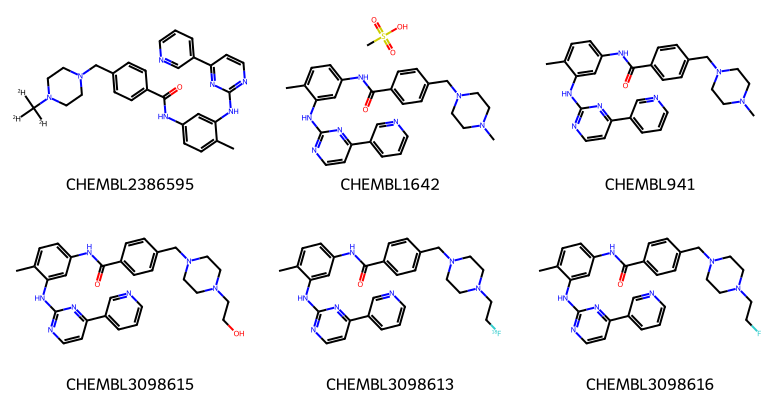

In [55]:
raw_mols = [Chem.MolFromSmiles(smi) for smi in df["smiles"]]
Draw.MolsToGridImage(
    [m for m in raw_mols if m is not None],
    legends=[i for i, m in zip(df["identifier"], raw_mols) if m is not None],
    molsPerRow=3, subImgSize=(260, 200),
)

## Remove duplicates

Here we remove isotope and salt duplicates to obtain a set of distinct N_LIGANDS. This could be managed by gypsum-dl directly

In [56]:
from rdkit.Chem.MolStandardize import rdMolStandardize

# Parse and sanitize the smiles
records = []
for identifier, smi in zip(df["identifier"], df["smiles"]):
    mol = Chem.MolFromSmiles(smi)            # None if parsing/sanitization fails
    if mol is None:
        print(f"  dropped {identifier}: could not parse/sanitize {smi!r}")
        continue
    records.append({"identifier": identifier, "mol": mol})

# Standardize and desalt
largest_fragment = rdMolStandardize.LargestFragmentChooser()
for r in records:
    parent  = largest_fragment.choose(r["mol"])    # strip salts / solvents
    cleaned = rdMolStandardize.Cleanup(parent)     # normalize
    r["std_mol"] = cleaned
    r["std_smiles"] = Chem.MolToSmiles(cleaned)

# De-duplicate isotopes
def isotope_stripped_smiles(mol):
    """Canonical SMILES with all isotope labels cleared - identifies isotopologues."""
    stripped = Chem.Mol(mol)
    for atom in stripped.GetAtoms():
        atom.SetIsotope(0)
    return Chem.MolToSmiles(stripped)

groups = {}
for r in records:
    groups.setdefault(isotope_stripped_smiles(r["std_mol"]), []).append(r)

deduped = []
for key, group in groups.items():
    if len(group) == 1:
        deduped.append(group[0])
        continue
    # Prefer the group member with no isotope labels at all; otherwise keep the first.
    representative = next((r for r in group if r["std_smiles"] == key), group[0])
    deduped.append(representative)
    for r in group:
        if r is not representative:
            print(f"  {r['identifier']}: isotopologue of {representative['identifier']} "
                  f"(identical once isotope labels are removed) -> dropped as redundant for docking")

print(f"\n{len(records)} standardized -> {len(deduped)} after isotope-dedup")
records = deduped

# Keep just N_LIGAND
if len(records) >= N_LIGANDS:
    records = records[:N_LIGANDS]
    print(f"Keeping {N_LIGANDS} ligands")
    

  CHEMBL941: isotopologue of CHEMBL1642 (identical once isotope labels are removed) -> dropped as redundant for docking
  CHEMBL3098613: isotopologue of CHEMBL3098616 (identical once isotope labels are removed) -> dropped as redundant for docking

6 standardized -> 4 after isotope-dedup
Keeping 3 ligands


### Protonation at physiological pH

A molecule's **protonation (ionization) state** depends on the **pKa** of its ionizable groups and the
**pH** of the environment (~7.4 in blood). It sets the net **charge** and the **H-bond donor/acceptor**
pattern — both of which change docking scores and poses. So we must fix it *before* docking.

**RDKit alone cannot do this.** `Chem.AddHs` only adds hydrogens consistent with the structure but it has **no pKa model** and will not deprotonate an acid or protonate a base for a target
pH.

In [57]:
demo = Chem.MolFromSmiles("OC(=O)CCN")   # beta-alanine: carboxylic acid (pKa~4) + amine (pKa~10)
print("As drawn (neutral):  ", Chem.MolToSmiles(demo))
print("After RDKit AddHs:   ", Chem.MolToSmiles(Chem.AddHs(demo)),
      " <- still neutral; RDKit ionized nothing")
print()
print("At pH 7.4 the dominant species is the zwitterion:  [O-]C(=O)CC[NH3+]")
print("Deciding that needs a pKa-aware tool -> Gypsum-DL / Dimorphite-DL (section 9).")

As drawn (neutral):   NCCC(=O)O
After RDKit AddHs:    [H]OC(=O)C([H])([H])C([H])([H])N([H])[H]  <- still neutral; RDKit ionized nothing

At pH 7.4 the dominant species is the zwitterion:  [O-]C(=O)CC[NH3+]
Deciding that needs a pKa-aware tool -> Gypsum-DL / Dimorphite-DL (section 9).


## Prepare for virtual screening with Gypsum-DL

**[Gypsum-DL](https://durrantlab.pitt.edu/gypsum-dl/)** (Ropp *et al.*, *J. Cheminform.* 2019) turns each SMILES into 3D, docking-ready model(s) accounting for alternate ionization, tautomeric, chiral, cis/trans isomeric, and ring-conformational forms. For every molecule it:

- **Desalts** and keep the largest fragment.
- **Ionizes** with **Dimorphite-DL** across a pH *range* (not a single pH).
- **Enumerates tautomers** (MolVS) and any **unspecified stereocenters / cis-trans bonds**.
- Generates 3D models, samples alternate **non-aromatic ring conformers**, then optimizes geometry with the UFF force field.

<div style="display: flex; gap: 10%; align-items: flex-start;">
  <img src="imgs/gypsum-dl_wf.png" style="width: 35%;" alt="Gypsum-DL workflow">
  <img src="imgs/gypsum-dl_steps.png" style="width: 40%;" alt="Gypsum-DL transformation types">
</div>

Rather than commit to one "most likely" state, it keeps up to `max_variants_per_compound` distinct forms per molecule — a binding pocket can stabilize a state that's rare in bulk solution.

### Dimorphite-DL ionization algorithm

**[Dimorphite-DL](https://doi.org/10.1186/s13321-019-0336-9)** doesn't calculate a pKa from first principles. It works using empirical rules in two steps:

1. **Pattern-match.** Every atom is checked against **38 predefined ionizable substructures** (amines, carboxylic acids, phenols, amides, aromatic nitrogens, …) using SMARTS queries. Each substructure was pre-assigned an empirical pKa *range*, `[μ − nσ, μ + nσ]`, by averaging the experimental pKa values of ~1,938 real reference molecules that contain it (μ = mean, σ = standard deviation, *n* = a user-tunable "pKa precision factor", default 1.0). Matching follows a strict priority order, so each atom is claimed by exactly *one* category.
2. **Compare to the pH window.** That substructure's pKa range is compared against the user-specified `[min_ph, max_ph]`. If the two ranges don't overlap, Dimorphite-DL commits to a single state (protonated or deprotonated); if they *do* overlap, it outputs **both** states as separate molecules.

This is fast because it's just a lookup — but it also means the "pKa" for a given atom depends only on which of the 38 fixed categories matched it, not on the rest of the molecule. Some well-documented failure modes follow directly from that:

- **Tertiary amides get scored as basic amines.** Chemically, *all* amides (see below) are only weakly basic because the nitrogen's lone pair is delocalized into the carbonyl π-system (C=O), so protonating that nitrogen needs strongly acidic conditions, nowhere near physiological pH. But matching Dimorphite-DL's "amide" SMARTS pattern requires an **N–H** bond. A *tertiary* amide has no N–H, so the amide pattern simply never matches it; its nitrogen instead falls through to the generic tertiary-amine category, which *is* basic. The result: Dimorphite-DL predicts a proton is added near physiological pH, generating a spurious `+1` charge state.

<div style="text-align: center;">
  <img src="imgs/amides.png" style="width: 35%;" alt="Tertiary amide misclassified as a basic amine">
</div>

- **Indoles/pyrroles never get their low-pH protonated form.** Dimorphite-DL's aromatic-nitrogen logic distinguishes two situations: an *unprotonated* aromatic N like pyridine and a *protonated* aromatic N–H like pyrrole/indole. But pyrrole/indole are not further protonated at very low pH where they would be expected to protonate with a second H atom.

<div style="text-align: center;">
  <img src="imgs/pyrrole_indole.jpeg" style="width: 25%;" alt="Pyrrole/indole ring nitrogen vs. ring-carbon protonation">
</div>

Other examples where the algorithm will fail are:

- **Ring substituents shift the real pKa, but Dimorphite-DL only sees "phenol".** Electron-donating alkyl groups raise a phenol's pKa, while electron-withdrawing halogens lower it. Dimorphite-DL only has one "phenol" category with — it can't tell these substituted rings apart and protonates them incorrectly.

All these errors trace back to the limitations of the approach, Dimorphite-DL "assigns ionization states without regard for the larger intramolecular context" looking at only a few atoms around each ionizable site rather than the whole molecule.

### Limitations of Gypsum-dl

Gypsum-DL's output is a bounded, heuristic *sample* of reasonable forms, not an exhaustive or guaranteed-correct one:

- **Heuristic, not quantum.** Ionization/tautomer states come from **rule-based pKa/tautomer heuristics** (Dimorphite-DL, MolVS) — plausible, not guaranteed. To stay tractable, Gypsum-DL drops ionization states whose charge deviates from neutral by ≥3 *e*, and keeps only the `max_variants_per_compound` combinations with the lowest UFF energy. It has no way to know which variant your target actually binds.
- **Drug-like molecules only.** Gypsum-DL is designed for small, drug-like inputs. Larger molecules (peptides, macrocycles) can take a very long time to process.
- **Tautomers can flip chirality.** MolVS occasionally proposes tautomers that change the number of chiral centers. Gypsum-DL rejects these by default; pass `--let_tautomers_change_chirality` to keep them instead.
- **Durrant-Lab filters are off.** This run doesn't pass `--use_durrant_lab_filters`, so some substructures that are technically possible but chemically improbable may survive into the output.
- **Constrained ring systems can fail to embed in 3D.** Highly constrained ring systems (e.g. adamantane-like cages) sometimes need a higher `--thoroughness` than the default used here.
- **Memory at scale.** Large libraries can need substantial memory to process.

We write the molecules to a `.smi` file (`SMILES<TAB>identifier`) and run Gypsum-DL over pH 7.0–8.0.

In [58]:
# Write analog molecules in a new file
smi_path = os.path.join(WORK_DIR, "standardized_ligands.smi")
with open(smi_path, "w") as fh:
    for rec in records:
        record_title = rec["identifier"]
        record_smi   = rec["std_smiles"]
        fh.write(f"{record_smi}\t{record_title}\n")
print("Wrote", smi_path)

# New folder for the gypsum-dl output
gypsum_out = os.path.join(WORK_DIR, "gypsum_out")
shutil.rmtree(gypsum_out, ignore_errors=True)
os.makedirs(gypsum_out, exist_ok=True)

# Find gypsum-dl binary path
import sys
gypsum_bin = os.path.join(os.path.dirname(sys.executable), "gypsum-dl")
if not os.path.exists(gypsum_bin):
    gypsum_bin = shutil.which("gypsum-dl") or "gypsum-dl"

# Call gypsum-dl
cmd = [
    gypsum_bin,
    "--source", smi_path,
    "--output_folder", gypsum_out,
    "--min_ph", str(MIN_PH), "--max_ph", str(MAX_PH), "--pka_precision", str(PKA_PRECISION),
    "--max_variants_per_compound", str(MAX_VARIANTS),
    "--job_manager", "multiprocessing", "--num_processors", "4",
]
print("Running:", " ".join(cmd), "\n")
res = subprocess.run(cmd, capture_output=True, text=True)

# Print std output and stderror if needed
print(res.stdout[-1500:])
if res.returncode != 0:
    print("STDERR:\n", res.stderr[-1500:])
    raise RuntimeError("Gypsum-DL failed")

Wrote ligand_prep_out/standardized_ligands.smi
Running: /home/pnavarro/miniforge3/envs/biobb_vs_ligprep/bin/gypsum-dl --source ligand_prep_out/standardized_ligands.smi --output_folder ligand_prep_out/gypsum_out --min_ph 7.0 --max_ph 8.0 --pka_precision 0.5 --max_variants_per_compound 2 --job_manager multiprocessing --num_processors 4 

C(\O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
            Mol #1:
                Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
Converting all molecules to 3D structures.
Generating several conformers of molecules with non-aromatic rings (boat vs.
    chair, etc.)...
Minimizing all 3D molecular structures...
    Contents of MolContainers
        MolContainer #0 (CHEMBL2386595)
            Mol #0: [2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(Nc4nccc(-
                c5cccnc5)n4)c3)cc2)CC1
            Mol #1: [2H]C([2H])([2H])N1CCN(Cc2ccc(/C(O)=N/c3ccc(C)c(Nc4nccc(-
                c5cccnc5)n4)c3)cc2)CC1
        MolContainer #1 (C

## Load results

Gypsum-DL writes everything to a single `gypsum_dl_success.sdf`. Its **first record is an empty
placeholder** holding the run parameters, so we skip any molecule with zero atoms. We keep the 3D
coordinates and explicit hydrogens Gypsum produced.

In [59]:
def alnum(s):
    return "".join(c for c in s if c.isalnum())

success_sdf = os.path.join(gypsum_out, "gypsum_dl_success.sdf")
supplier = Chem.SDMolSupplier(success_sdf, removeHs=False)   # keep protonation!

prepared = []
for mol in supplier:
    if mol is None or mol.GetNumAtoms() == 0:                # skip Gypsum's params placeholder
        continue
    title = alnum(mol.GetProp("_Name")) if mol.HasProp("_Name") else f"ligand{len(prepared)}"  # fall back to an index if Gypsum dropped the name
    mol.SetProp("_Name", title)
    has_3d = mol.GetNumConformers() > 0 and mol.GetConformer().Is3D()  # sanity check: confirm Gypsum actually embedded 3D coords
    prepared.append(mol)
    print(f"  {title:24s} atoms={mol.GetNumAtoms():3d}  3D={has_3d}")

print(f"\n{len(prepared)} prepared 3D molecules")
assert prepared, "No molecules survived Gypsum-DL preparation."

  CHEMBL2386595            atoms= 68  3D=True
  CHEMBL2386595            atoms= 68  3D=True
  CHEMBL1642               atoms= 69  3D=True
  CHEMBL1642               atoms= 69  3D=True
  CHEMBL3098615            atoms= 72  3D=True
  CHEMBL3098615            atoms= 72  3D=True

6 prepared 3D molecules


### Visualize the prepared molecules in 3D

A quick visual check that Gypsum-DL produced sane 3D geometry (and that the explicit hydrogens /
protonation survived). Pick a variant from the dropdown to view it, one at a time.

In [60]:
import nglview
from ipywidgets import interact, Dropdown

labels = [f"{i}: {m.GetProp('_Name')}" for i, m in enumerate(prepared)]

def show_ligand(i):
    view = nglview.show_rdkit(prepared[i])
    view.add_representation("licorice")
    view.center()
    display(view)

interact(show_ligand, i=Dropdown(options=list(zip(labels, range(len(prepared)))), description="Ligand"));

interactive(children=(Dropdown(description='Ligand', options=(('0: CHEMBL2386595', 0), ('1: CHEMBL2386595', 1)…

## Check the charges

Check the charge of the different ligands

In [61]:
qc = []
for m in prepared:
    qc.append({
        "identifier": m.GetProp("_Name"),
        "net_charge": sum(a.GetFormalCharge() for a in m.GetAtoms())
    })
qc_df = pd.DataFrame(qc).set_index("identifier")
qc_df

,net_charge
identifier,
CHEMBL2386595,0
CHEMBL2386595,0
CHEMBL1642,1
CHEMBL1642,1
CHEMBL3098615,0
CHEMBL3098615,0


## Write the docking-ready SDF

Write the prepared molecules to `data/ligands/`, then read them back to confirm the file is valid:
every record has a 3D conformer, explicit hydrogens, and an alphanumeric title.

In [62]:
os.makedirs(os.path.dirname(OUTPUT_SDF), exist_ok=True)
writer = Chem.SDWriter(OUTPUT_SDF)
for mol in prepared:
    writer.write(mol)
writer.close()
print(f"Wrote {len(prepared)} molecules to {OUTPUT_SDF}")

# --- Verify: re-read the file we just wrote as a round-trip check that the SDF is well-formed
# and that virtual_screening (which reads .sdf input as-is, with no re-protonation) will get what we intend.
check = [m for m in Chem.SDMolSupplier(OUTPUT_SDF, removeHs=False) if m is not None]
assert len(check) == len(prepared), "record count mismatch"
for m in check:
    assert m.GetNumConformers() > 0 and m.GetConformer().Is3D(), f"{m.GetProp('_Name')}: no 3D coords"  # docking needs real 3D geometry
    assert any(a.GetSymbol() == "H" for a in m.GetAtoms()), f"{m.GetProp('_Name')}: no explicit Hs"      # protonation state must survive the round-trip
    assert m.GetProp("_Name").isalnum(), f"{m.GetProp('_Name')}: non-alphanumeric title"                # virtual_screening uses the title as an output folder name
print("Verified:", len(check), "records, all 3D with explicit Hs and alphanumeric titles.")

Wrote 6 molecules to data/ligands/imatinib_analogs_prepared.sdf
Verified: 6 records, all 3D with explicit Hs and alphanumeric titles.


## 10. Wrap-up

You went from a single reference drug to a small, **protonated, 3D, docking-ready SDF**:

```
ChEMBL  ->  Gypsum-DL (protonate + 3D)  ->  SDF
```

Feed it straight into the virtual-screening tutorial by pointing `--ligand_lib` at the file:

```bash
virtual_screening --ligand_lib data/ligands/imatinib_analogs_prepared.sdf ...
```

or set `ligand_lib = "data/ligands/imatinib_analogs_prepared.sdf"` in
[`notebook_tutorial.ipynb`](notebook_tutorial.ipynb). Remember: for `.sdf` input the workflow trusts
these coordinates and hydrogens **as-is** — no re-protonation downstream.

### Limitations recap
- **Protonation** uses empirical pKa and keeps only the dominant microstate(s) in the pH window
- **One 3D conformer** per variant; the bioactive conformer may differ, and force-field ≠ quantum
  energies. Docking re-samples torsions but not ring/stereo inversions.